In [141]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Load 6 months of data into a single pandas dataset and restrict to only single family residences

In [142]:
from pathlib import Path
data_dir = Path("Data")

training_files = [
    data_dir / 'CRMLSSold202509.csv',
    data_dir / 'CRMLSSold202510.csv',
    data_dir / 'CRMLSSold202511.csv',
    data_dir / 'CRMLSSold202512.csv',
    data_dir / 'CRMLSSold202601.csv',
    data_dir / 'CRMLSSold202602.csv',
    data_dir / 'CRMLSSold202603.csv'
]
dfs = [pd.read_csv(f) for f in training_files]
df = pd.concat(dfs, ignore_index=True)

df = df[
    (df['PropertyType'] == 'Residential') &
    (df['PropertySubType'] == 'SingleFamilyResidence')
    ]

cols = ['ClosePrice', 'LivingArea', 'BedroomsTotal', 
        'BathroomsTotalInteger', 'LotSizeSquareFeet']

#convert columns to numeric
for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df[cols].describe()

C:\Users\d_sru\AppData\Local\Temp\ipykernel_34112\2726663097.py:13: DtypeWarning: Columns (4,74) have mixed types. Specify dtype option on import or set low_memory=False.
  dfs = [pd.read_csv(f) for f in training_files]


,ClosePrice,LivingArea,BedroomsTotal,BathroomsTotalInteger,LotSizeSquareFeet
count,7.089600e+04,70861.000000,70896.000000,70894.000000,6.968600e+04
mean,1.343628e+06,2044.413329,3.493822,2.628558,5.805479e+05
std,9.137310e+06,1034.466036,0.969856,1.123669,2.318620e+07
min,1.750000e+00,0.000000,0.000000,0.000000,0.000000e+00
25%,6.165000e+05,1382.000000,3.000000,2.000000,5.663000e+03
50%,8.750000e+05,1814.000000,3.000000,2.000000,7.255000e+03
75%,1.385000e+06,2436.000000,4.000000,3.000000,1.045400e+04
max,9.895000e+08,31068.000000,22.000000,23.000000,1.938943e+09


ClosePrice Distribution

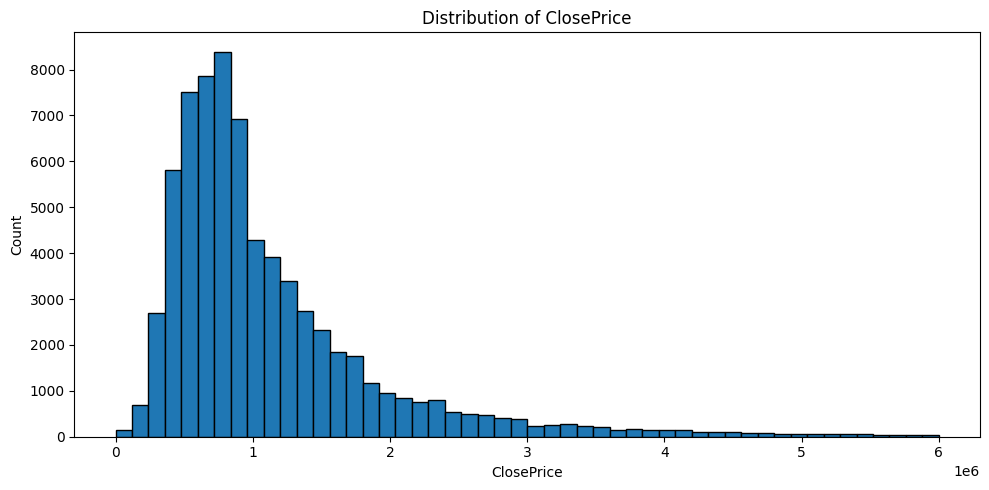

In [143]:
import matplotlib.pyplot as plt
import numpy as np

#filter out extreme values for ClosePrice, set a threshold of 6 million
filtered_close_price = df[df['ClosePrice'] <= 6000000]['ClosePrice']

plt.figure(figsize=(10, 5))
plt.hist(filtered_close_price.dropna(), bins=50, edgecolor='black')
plt.title('Distribution of ClosePrice')
plt.xlabel('ClosePrice')
plt.ylabel('Count') #how many homes were sold at each price point
plt.tight_layout()
plt.show()

LivingArea Distribution

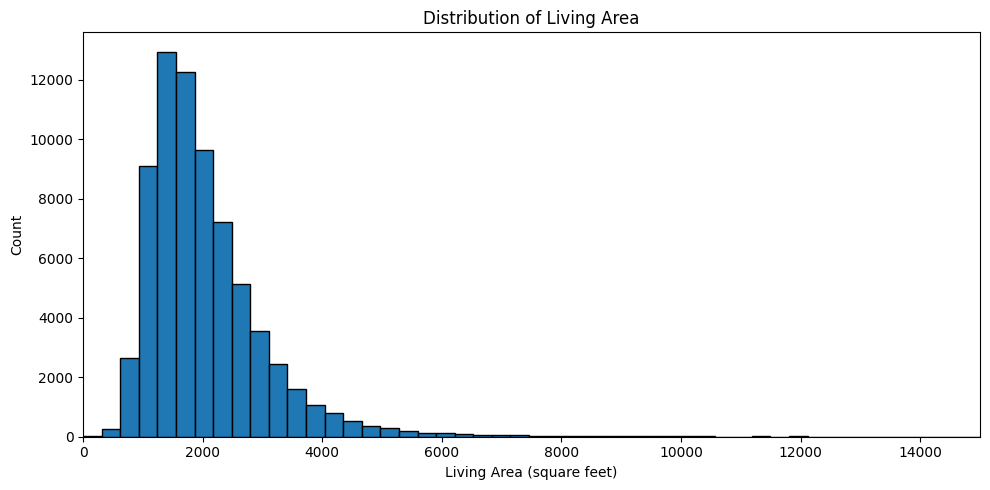

In [144]:
plt.figure(figsize=(10, 5))
plt.hist(df['LivingArea'].dropna(), bins=100, edgecolor='black')
plt.title('Distribution of Living Area')
plt.xlabel('Living Area (square feet)')
plt.xlim(0, 15000)
plt.ylabel('Count') #how many homes have the same living area
plt.tight_layout()
plt.show()

Distribution of Bedrooms

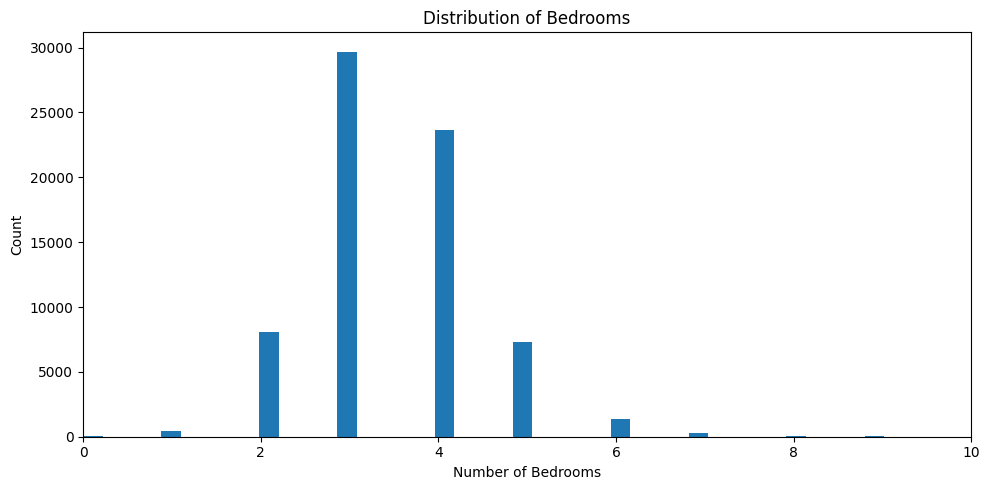

In [145]:
plt.figure(figsize=(10, 5))
plt.hist(df['BedroomsTotal'].dropna(), bins=100)
plt.title('Distribution of Bedrooms')
plt.xlabel('Number of Bedrooms')
plt.xlim(0, 10)
plt.ylabel('Count') #how many homes have the same number of bedrooms
plt.tight_layout()
plt.show()

Distribution of Bathrooms

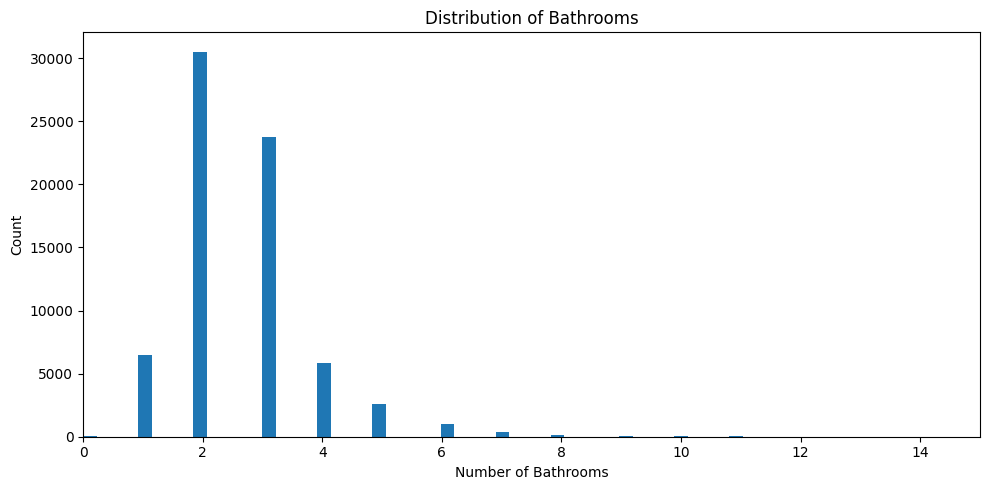

In [146]:
plt.figure(figsize=(10, 5))
plt.hist(df['BathroomsTotalInteger'].dropna(), bins=100)
plt.title('Distribution of Bathrooms')
plt.xlabel('Number of Bathrooms')
plt.xlim(0, 15)
plt.ylabel('Count') #how many homes have the same number of bathrooms
plt.tight_layout()
plt.show()

Distribution of Lot Size

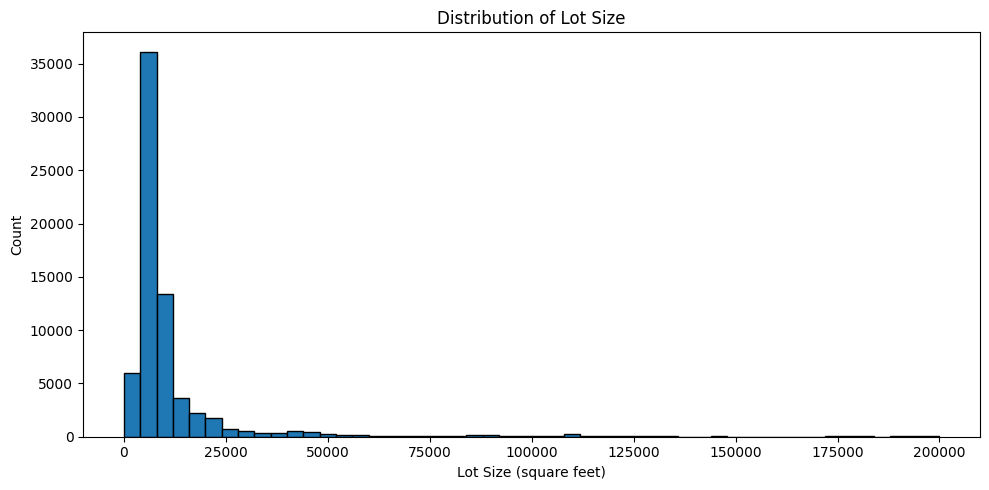

In [147]:
#filter out extreme values for LotSizeSquareFeet, set a threshold of 200,000
filtered_lot_size = df[df['LotSizeSquareFeet'] <= 200000]['LotSizeSquareFeet']

plt.figure(figsize=(10, 5))
plt.hist(filtered_lot_size.dropna(), bins=50, edgecolor='black')
plt.title('Distribution of Lot Size')
plt.xlabel('Lot Size (square feet)')
plt.ylabel('Count') #how many homes were sold at each lot size
plt.tight_layout()
plt.show()

Results:

- Close Price: most houses are sold between $750k to $900k, with outliers existing above $3M
- Living Area: most houses have around 1,500 to 2,000 square footage of living area
- Bedrooms: most houses have 3-4 bedrooms
- Bathrooms: most houses have 2-3 bathrooms
- Lot Size: most houses have a lot size of around 10k to 15k square footage